In [1]:
# CELL 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
from utils import visual_compare

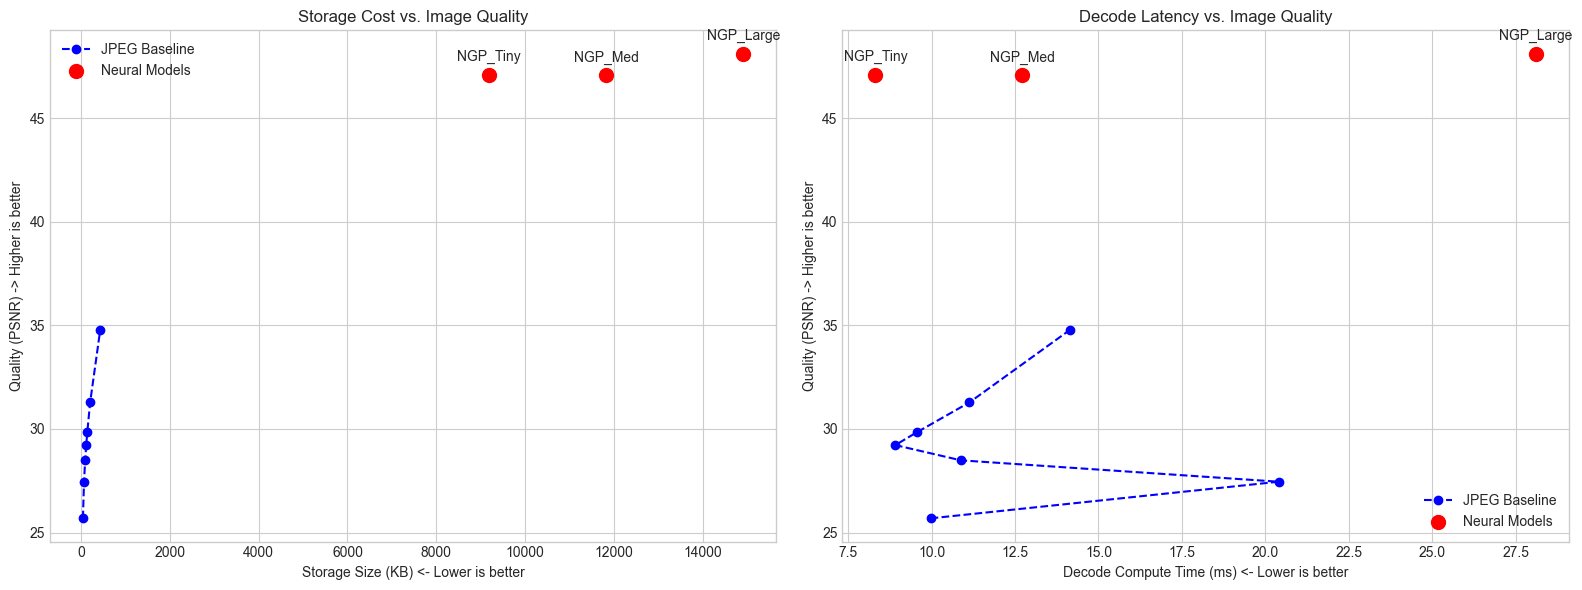

In [6]:
# CELL 2: The Pareto Curve Generator
df_jpeg = pd.read_csv("results/jpeg_metrics.csv")
df_neural = pd.read_csv("results/neural_metrics.csv")

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Storage vs Quality
ax1.plot(df_jpeg["Size_KB"], df_jpeg["PSNR"], marker='o', linestyle='--', color='blue', label="JPEG Baseline")
ax1.scatter(df_neural["Size_KB"], df_neural["PSNR"], color='red', s=100, zorder=5, label="Neural Models")

for i, row in df_neural.iterrows():
    ax1.annotate(row["Method"], (row["Size_KB"], row["PSNR"]), textcoords="offset points", xytext=(0,10), ha='center')

ax1.set_xlabel("Storage Size (KB) <- Lower is better")
ax1.set_ylabel("Quality (PSNR) -> Higher is better")
ax1.set_title("Storage Cost vs. Image Quality")
ax1.legend()

# Graph 2: Compute vs Quality
ax2.plot(df_jpeg["Latency_ms"], df_jpeg["PSNR"], marker='o', linestyle='--', color='blue', label="JPEG Baseline")
ax2.scatter(df_neural["Latency_ms"], df_neural["PSNR"], color='red', s=100, zorder=5, label="Neural Models")

for i, row in df_neural.iterrows():
    ax2.annotate(row["Method"], (row["Latency_ms"], row["PSNR"]), textcoords="offset points", xytext=(0,10), ha='center')

ax2.set_xlabel("Decode Compute Time (ms) <- Lower is better")
ax2.set_ylabel("Quality (PSNR) -> Higher is better")
ax2.set_title("Decode Latency vs. Image Quality")
ax2.legend()

plt.tight_layout()
plt.show()

Comparing JPEG (Q10) to SIREN Large:


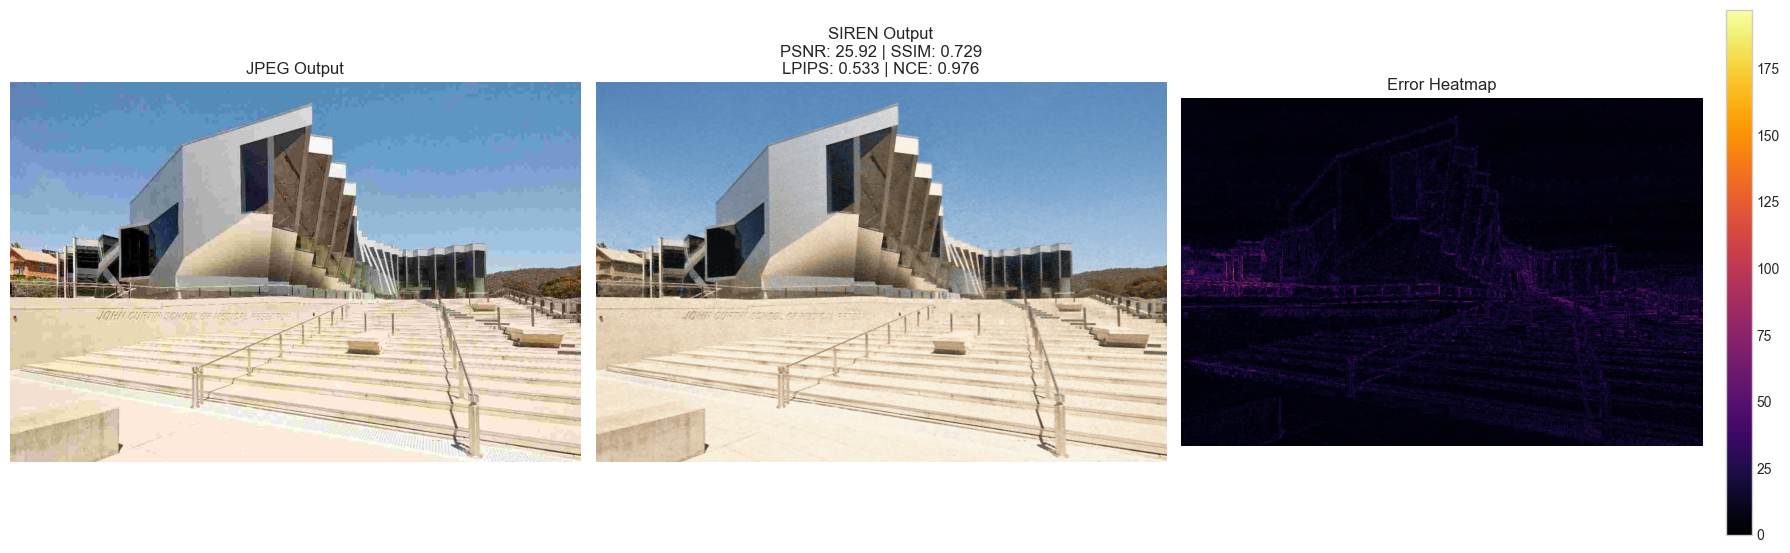

Proving Spectral Bias (Why standard ReLU fails):


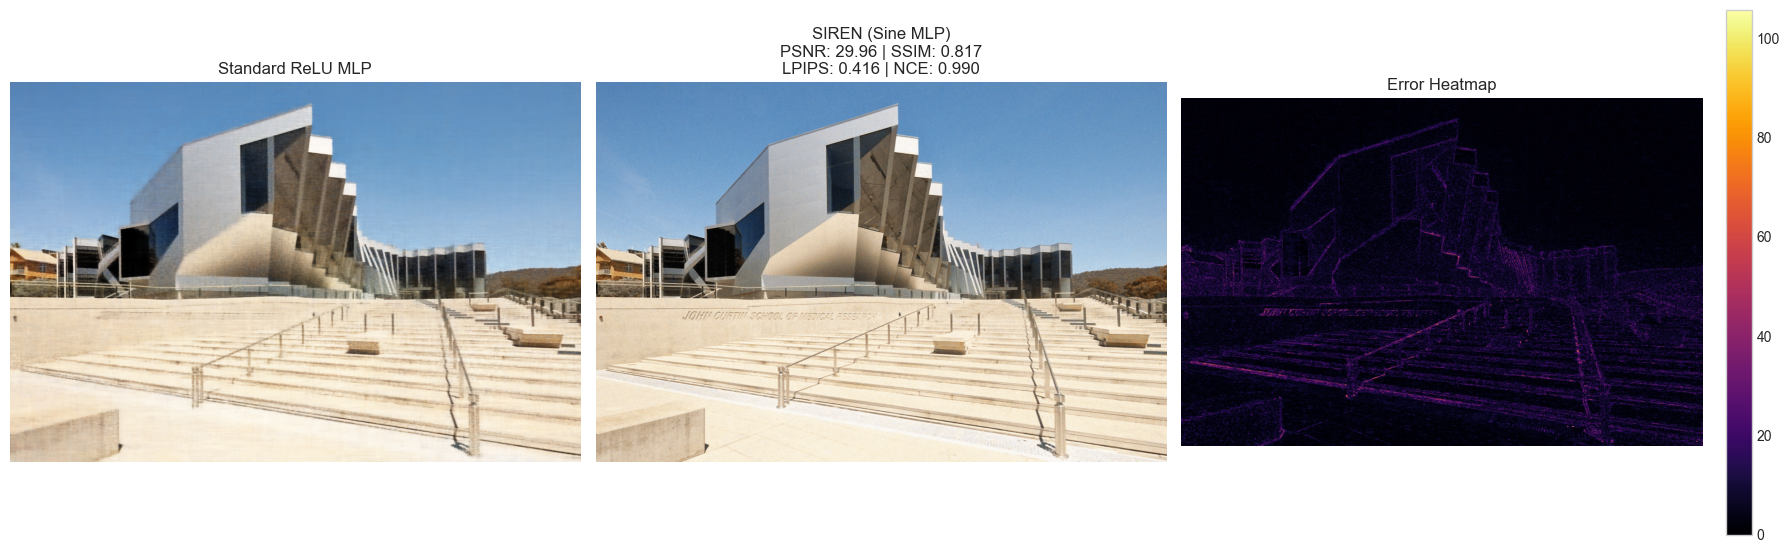

In [3]:
# CELL 3: The Ultimate Visual Proof
# Prove why ReLU fails and SIREN wins, or compare JPEG to SIREN
print("Comparing JPEG (Q10) to SIREN Large:")
visual_compare("images/JPEG_Q10.jpg", "images/SIREN_Large.png", "JPEG Output", "SIREN Output")

print("Proving Spectral Bias (Why standard ReLU fails):")
visual_compare("images/ReLU_Baseline.png", "images/SIREN_Med.png", "Standard ReLU MLP", "SIREN (Sine MLP)")